In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Load enriched train and test data
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_enriched.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_enriched.csv")

# Remove price outliers
price_mask_train = (train_data["ClosePrice"] >= 100_000) & (train_data["ClosePrice"] <= 10_000_000)
price_mask_test  = (test_data["ClosePrice"]  >= 100_000) & (test_data["ClosePrice"]  <= 10_000_000)

train_clean = train_data[price_mask_train].copy()
test_clean  = test_data[price_mask_test].copy()

print(f"Train rows: {len(train_clean)}")
print(f"Test rows:  {len(test_clean)}")

Train rows: 49441
Test rows:  11965


In [2]:
# Feature set — using old reliable features
feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
    "HasHOA", "LotLivingRatio", "UnifiedDistrict_encoded",
]

X_train = train_clean[feature_cols]
y_train = train_clean["ClosePrice"]
X_test  = test_clean[feature_cols]
y_test  = test_clean["ClosePrice"]

print(f"Features: {len(feature_cols)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")

Features: 24
X_train shape: (49441, 24)
X_test shape:  (11965, 24)
Missing values in X_train: 0


In [3]:
from xgboost import XGBRegressor

# Train XGBoost with default parameters first
model_xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)
r2_xgb  = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("=" * 40)
print("XGBOOST (default parameters)")
print("=" * 40)
print(f"R² Score:            {r2_xgb:.4f}")
print(f"Mean Absolute Error: ${mae_xgb:,.0f}")
print("=" * 40)

XGBOOST (default parameters)
R² Score:            0.8585
Mean Absolute Error: $203,350


In [4]:
from lightgbm import LGBMRegressor

# Train LightGBM with default parameters
model_lgbm = LGBMRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
model_lgbm.fit(X_train, y_train)

y_pred_lgbm = model_lgbm.predict(X_test)
r2_lgbm  = r2_score(y_test, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

print("=" * 40)
print("LIGHTGBM (default parameters)")
print("=" * 40)
print(f"R² Score:            {r2_lgbm:.4f}")
print(f"Mean Absolute Error: ${mae_lgbm:,.0f}")
print("=" * 40)

LIGHTGBM (default parameters)
R² Score:            0.8501
Mean Absolute Error: $215,932


In [5]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Tuning combinations to try
xgb_params = [
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.1},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.05},
]

lgbm_params = [
    {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.1},
    {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.05},
    {"n_estimators": 500, "max_depth": 4, "learning_rate": 0.05},
]

print("XGBoost Tuning:")
print("=" * 60)
best_xgb_r2 = 0
best_xgb_params = None

for params in xgb_params:
    model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Params: {params}")
    print(f"  R²: {r2:.4f}  MAE: ${mae:,.0f}")
    if r2 > best_xgb_r2:
        best_xgb_r2 = r2
        best_xgb_params = params

print(f"\nBest XGBoost params: {best_xgb_params}")
print(f"Best XGBoost R²:     {best_xgb_r2:.4f}")

print("\nLightGBM Tuning:")
print("=" * 60)
best_lgbm_r2 = 0
best_lgbm_params = None

for params in lgbm_params:
    model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1, **params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Params: {params}")
    print(f"  R²: {r2:.4f}  MAE: ${mae:,.0f}")

XGBoost Tuning:
Params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
  R²: 0.8394  MAE: $226,096
Params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
  R²: 0.8641  MAE: $200,572
Params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05}
  R²: 0.8476  MAE: $218,033

Best XGBoost params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
Best XGBoost R²:     0.8641

LightGBM Tuning:
Params: {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
  R²: 0.8399  MAE: $226,697
Params: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05}
  R²: 0.8542  MAE: $208,947
Params: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05}
  R²: 0.8468  MAE: $219,775


In [6]:
from sklearn.ensemble import RandomForestRegressor

# Train best XGBoost
model_xgb_best = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=0
)
model_xgb_best.fit(X_train, y_train)
y_pred_xgb_best = model_xgb_best.predict(X_test)

# Train best LightGBM
model_lgbm_best = LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, n_jobs=-1, verbosity=-1
)
model_lgbm_best.fit(X_train, y_train)
y_pred_lgbm_best = model_lgbm_best.predict(X_test)

# Train Random Forest for comparison
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

# Full comparison table
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression (baseline)",
        "Random Forest",
        "XGBoost (tuned)",
        "LightGBM (tuned)",
    ],
    "R2_Score": [
        0.2995,
        round(r2_score(y_test, y_pred_rf), 4),
        round(r2_score(y_test, y_pred_xgb_best), 4),
        round(r2_score(y_test, y_pred_lgbm_best), 4),
    ],
    "MAE": [
        571147,
        round(mean_absolute_error(y_test, y_pred_rf), 0),
        round(mean_absolute_error(y_test, y_pred_xgb_best), 0),
        round(mean_absolute_error(y_test, y_pred_lgbm_best), 0),
    ]
})

print("=" * 55)
print("FULL MODEL COMPARISON")
print("=" * 55)
print(comparison.to_string(index=False))
print("=" * 55)

FULL MODEL COMPARISON
                       Model  R2_Score      MAE
Linear Regression (baseline)    0.2995 571147.0
               Random Forest    0.8581 186208.0
             XGBoost (tuned)    0.8641 200572.0
            LightGBM (tuned)    0.8542 208947.0


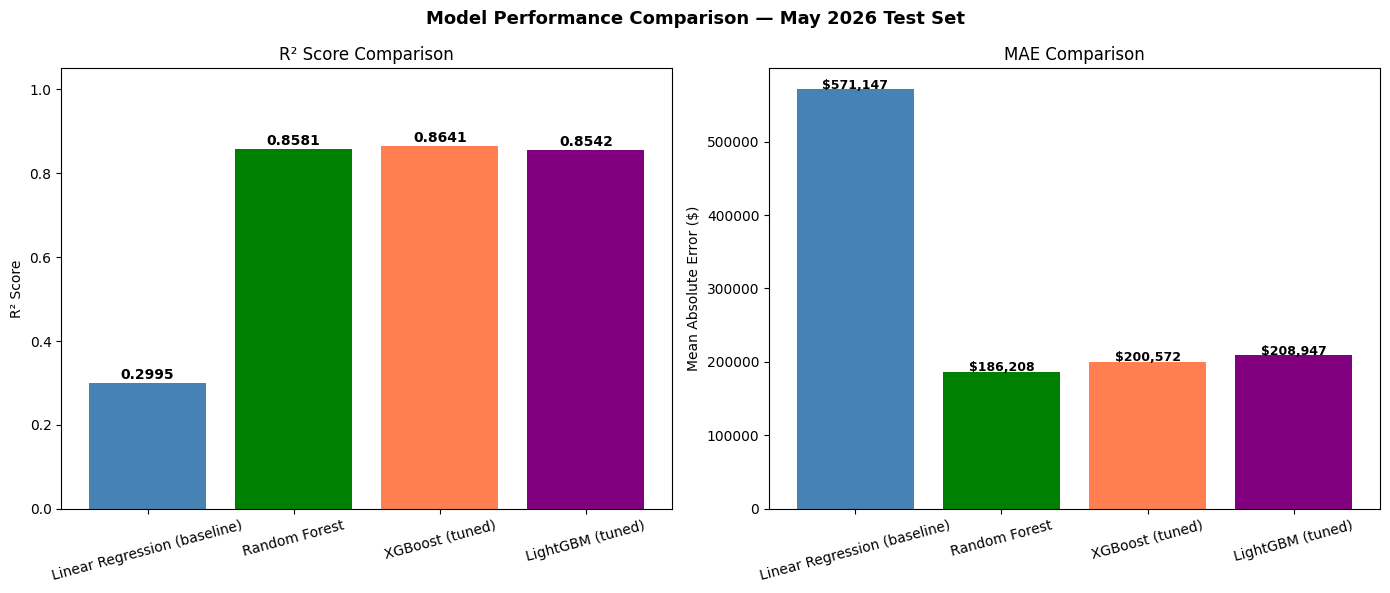

In [7]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ["steelblue", "green", "coral", "purple"]

# R² comparison
bars1 = axes[0].bar(comparison["Model"], comparison["R2_Score"], color=colors)
for bar, val in zip(bars1, comparison["R2_Score"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=15)

# MAE comparison
bars2 = axes[1].bar(comparison["Model"], comparison["MAE"], color=colors)
for bar, val in zip(bars2, comparison["MAE"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f"${val:,.0f}", ha="center", fontsize=9, fontweight="bold")
axes[1].set_title("MAE Comparison")
axes[1].set_ylabel("Mean Absolute Error ($)")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Model Performance Comparison — May 2026 Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

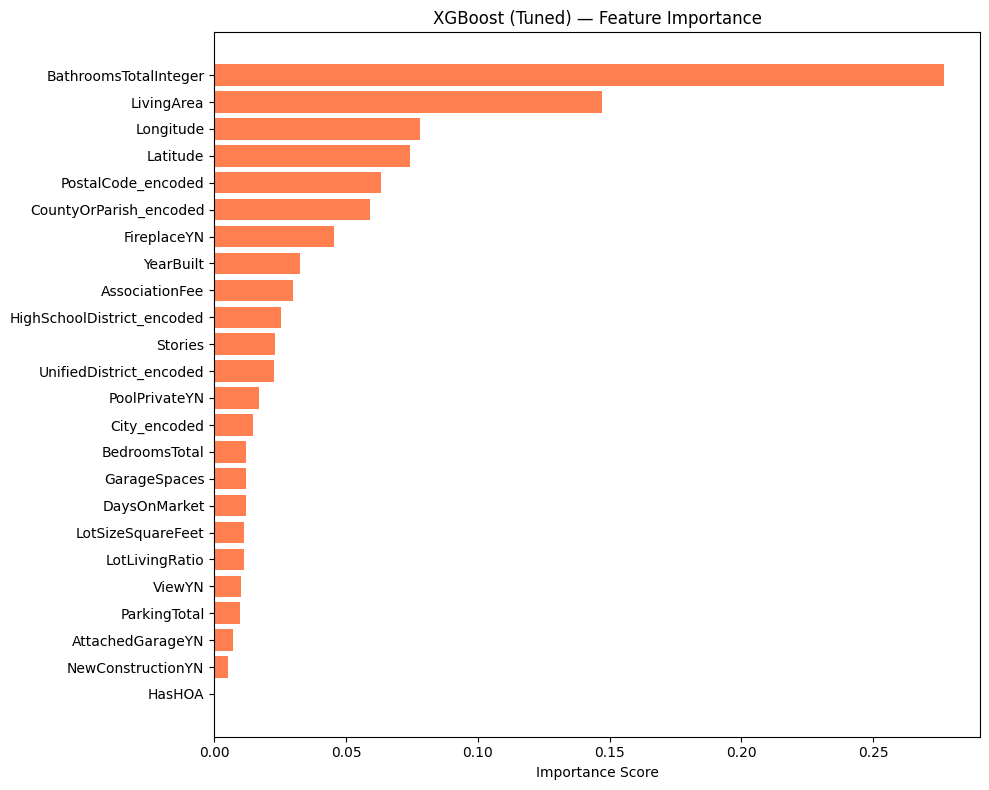

Top 10 most important features:
                   Feature  Importance
     BathroomsTotalInteger    0.276733
                LivingArea    0.146963
                 Longitude    0.078055
                  Latitude    0.074359
        PostalCode_encoded    0.063213
    CountyOrParish_encoded    0.059047
               FireplaceYN    0.045424
                 YearBuilt    0.032621
            AssociationFee    0.029836
HighSchoolDistrict_encoded    0.025225


In [8]:
# XGBoost feature importance
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model_xgb_best.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance["Feature"], importance["Importance"], color="coral")
plt.xlabel("Importance Score")
plt.title("XGBoost (Tuned) — Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(importance.head(10).to_string(index=False))